# 15 — Model Monitoring
## SunnyBest Retail Forecasting System

> **Purpose:** Compare weekly forecasts against actual sales from Supabase.  
> Track model accuracy over time and flag weeks where performance degrades.

### How monitoring works

| Step | What happens |
|------|--------------|
| Every Saturday | `generate_weekly_forecast.py` predicts next week's units |
| Following Saturday | Actual sales land in Supabase |
| This notebook | Compares forecast vs actual → computes WAPE, bias, MAE |
| Alert | If WAPE > 20%, the model needs investigation |

### Key metrics
- **MAE** — Mean Absolute Error: average units wrong per store-product per week
- **WAPE** — Weighted Absolute Percentage Error: total error as % of total actual demand
- **Bias** — are we consistently over or under predicting?

---
## 0. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import create_engine
from urllib.parse import quote_plus

plt.rcParams["figure.figsize"]    = (14, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
PALETTE = ["#4C72B0", "#C44E52", "#55A868", "#DD8452"]

FORECAST_PATH        = "../data/outputs/weekly_forecasts.csv"
WAPE_ALERT_THRESHOLD = 0.20

# ── DB connection ──────────────────────────────────────────
host     = "aws-1-eu-central-1.pooler.supabase.com"
port     = 5432
database = "postgres"
user     = "postgres.ogkdfmkybqtrsglcizzt"
password = quote_plus(os.getenv("SUPABASE_DB_PASSWORD", "Bonabosssfs01"))

engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}",
    pool_pre_ping=True,
    pool_recycle=300,
)

print("Setup complete")

Setup complete


---
## 1. Load Forecasts

> These are the predictions your model made **before** the week happened.  
> Generated by `generate_weekly_forecast.py` and saved to `data/outputs/weekly_forecasts.csv`.

In [2]:
forecasts = pd.read_csv(FORECAST_PATH)
forecasts["week_start"]  = pd.to_datetime(forecasts["week_start"])
forecasts["store_id"]    = forecasts["store_id"].astype(str)
forecasts["product_id"]  = pd.to_numeric(forecasts["product_id"], errors="coerce").astype(int)
forecasts["predicted_units"] = pd.to_numeric(forecasts["predicted_units"], errors="coerce")

print(f"Forecast rows : {len(forecasts):,}")
print(f"Forecast weeks: {forecasts['week_start'].nunique()}")
print(f"Date range    : {forecasts['week_start'].min().date()} → {forecasts['week_start'].max().date()}")
print()
display(forecasts.groupby(["week_start", "model_version"]).size().reset_index(name="rows"))

Forecast rows : 3,360
Forecast weeks: 3
Date range    : 2026-03-30 → 2026-05-11



,week_start,model_version,rows
0,2026-03-30,weekly_model_v4_promotions,840
1,2026-05-04,weekly_model_v3_calendar,840
2,2026-05-11,weekly_model_v3_calendar,840
3,2026-05-11,weekly_model_v3_calendar_2026_05,840


---
## 2. Load Actuals from Supabase

> Pull real weekly units sold for the same date range as the forecasts.  
> This is ground truth — what actually happened in stores.

In [3]:
min_date = forecasts["week_start"].min().date()

actuals = pd.read_sql(f"""
    SELECT
        DATE_TRUNC('week', date)::date  AS week_start,
        store_id::text                  AS store_id,
        product_id,
        SUM(units_sold)                 AS units_sold
    FROM core.fact_sales
    WHERE date >= '{min_date}'
    GROUP BY 1, 2, 3
    ORDER BY 1
""", engine)

actuals["week_start"] = pd.to_datetime(actuals["week_start"])
actuals["store_id"]   = actuals["store_id"].astype(str)
actuals["product_id"] = actuals["product_id"].astype(int)
actuals["units_sold"] = pd.to_numeric(actuals["units_sold"], errors="coerce")

print(f"Actual rows : {len(actuals):,}")
print(f"Actual weeks: {actuals['week_start'].nunique()}")
print(f"Date range  : {actuals['week_start'].min().date()} → {actuals['week_start'].max().date()}")

Actual rows : 5,040
Actual weeks: 6
Date range  : 2026-03-30 → 2026-05-04


---
## 3. Build Monitoring Table

> Join forecasts to actuals on `week_start + store_id + product_id`.  
> Compute error metrics at the row level (per store × product × week).

In [4]:
monitor = forecasts.merge(actuals, on=["week_start", "store_id", "product_id"], how="left")

monitor["abs_error"]    = (monitor["units_sold"] - monitor["predicted_units"]).abs()
monitor["signed_error"] = monitor["predicted_units"] - monitor["units_sold"]
monitor["ape"]          = monitor["abs_error"] / monitor["units_sold"].replace(0, np.nan)

# Rows with actuals vs waiting for actuals
has_actuals  = monitor["units_sold"].notna().sum()
no_actuals   = monitor["units_sold"].isna().sum()

print(f"Rows with actuals   : {has_actuals:,}  (can evaluate)")
print(f"Rows without actuals: {no_actuals:,}   (future weeks — wait for Saturday upload)")
print()
display(monitor.head(10))

Rows with actuals   : 1,680  (can evaluate)
Rows without actuals: 1,680   (future weeks — wait for Saturday upload)



,week_start,store_id,product_id,predicted_units,forecast_created_at,model_version,units_sold,abs_error,signed_error,ape
0,2026-03-30,1,1001,7.31,2026-04-06,weekly_model_v4_promotions,7.0,0.31,0.31,0.044286
1,2026-03-30,1,1002,12.27,2026-04-06,weekly_model_v4_promotions,15.0,2.73,-2.73,0.182000
2,2026-03-30,1,1003,24.83,2026-04-06,weekly_model_v4_promotions,13.0,11.83,11.83,0.910000
3,2026-03-30,1,1004,6.84,2026-04-06,weekly_model_v4_promotions,20.0,13.16,-13.16,0.658000
4,2026-03-30,1,1005,29.16,2026-04-06,weekly_model_v4_promotions,7.0,22.16,22.16,3.165714
5,2026-03-30,1,1006,25.23,2026-04-06,weekly_model_v4_promotions,12.0,13.23,13.23,1.102500
6,2026-03-30,1,1007,36.81,2026-04-06,weekly_model_v4_promotions,22.0,14.81,14.81,0.673182
7,2026-03-30,1,1008,38.38,2026-04-06,weekly_model_v4_promotions,6.0,32.38,32.38,5.396667
8,2026-03-30,1,1009,5.70,2026-04-06,weekly_model_v4_promotions,8.0,2.30,-2.30,0.287500
9,2026-03-30,1,1010,7.04,2026-04-06,weekly_model_v4_promotions,70.0,62.96,-62.96,0.899429


---
## 4. Weekly Performance Summary

> Aggregate errors by week to get WAPE, bias and alert status.  
> A week is flagged **Check Model** if WAPE > 20%.

In [5]:
weekly = (monitor.dropna(subset=["units_sold"])
          .groupby("week_start", as_index=False)
          .agg(
              actual_sum    =("units_sold",       "sum"),
              predicted_sum =("predicted_units",  "sum"),
              abs_error_sum =("abs_error",         "sum"),
              bias_sum      =("signed_error",       "sum"),
              item_count    =("product_id",         "count"),
          ))

weekly["WAPE"]     = (weekly["abs_error_sum"] / weekly["actual_sum"].replace(0, np.nan) * 100).round(2)
weekly["BIAS_PCT"] = (weekly["bias_sum"]      / weekly["actual_sum"].replace(0, np.nan) * 100).round(2)
weekly["MAE"]      = (weekly["abs_error_sum"] / weekly["item_count"]).round(4)
weekly["alert"]    = weekly["WAPE"].apply(
    lambda x: "⚠️ Check Model" if pd.notna(x) and x > WAPE_ALERT_THRESHOLD * 100 else "✅ OK"
)

display(weekly[["week_start", "actual_sum", "predicted_sum", "MAE", "WAPE", "BIAS_PCT", "alert"]])

,week_start,actual_sum,predicted_sum,MAE,WAPE,BIAS_PCT,alert
0,2026-03-30,12533.0,13570.90,20.2596,135.79,8.28,⚠️ Check Model
1,2026-05-04,10414.0,12138.26,3.2163,25.94,16.56,⚠️ Check Model


---
## 5. Overall Metrics

In [6]:
evaluated = monitor.dropna(subset=["units_sold"])

overall_mae  = evaluated["abs_error"].mean()
overall_wape = evaluated["abs_error"].sum() / evaluated["units_sold"].sum() * 100
overall_bias = evaluated["signed_error"].sum() / evaluated["units_sold"].sum() * 100
n_alerts     = (weekly["WAPE"] > WAPE_ALERT_THRESHOLD * 100).sum()

print("=" * 45)
print("  OVERALL MONITORING METRICS")
print("=" * 45)
print(f"  MAE            : {overall_mae:.4f} units")
print(f"  WAPE           : {overall_wape:.2f}%")
print(f"  Bias           : {overall_bias:+.2f}%  {'(over-predicting)' if overall_bias > 0 else '(under-predicting)'}")
print(f"  Weeks evaluated: {len(weekly)}")
print(f"  Alert weeks    : {n_alerts}")
print("=" * 45)

if n_alerts > 0:
    print(f"\n  ⚠️  {n_alerts} week(s) exceeded {WAPE_ALERT_THRESHOLD:.0%} WAPE threshold — investigate model drift.")
else:
    print(f"\n  ✅  All weeks within {WAPE_ALERT_THRESHOLD:.0%} WAPE threshold — model is healthy.")

  OVERALL MONITORING METRICS
  MAE            : 11.7379 units
  WAPE           : 85.94%
  Bias           : +12.04%  (over-predicting)
  Weeks evaluated: 2
  Alert weeks    : 2

  ⚠️  2 week(s) exceeded 20% WAPE threshold — investigate model drift.


---
## 6. Charts

### Chart 1 — WAPE Over Time
> Shows whether accuracy is improving, stable, or degrading.  
> Red bars = weeks that need investigation.

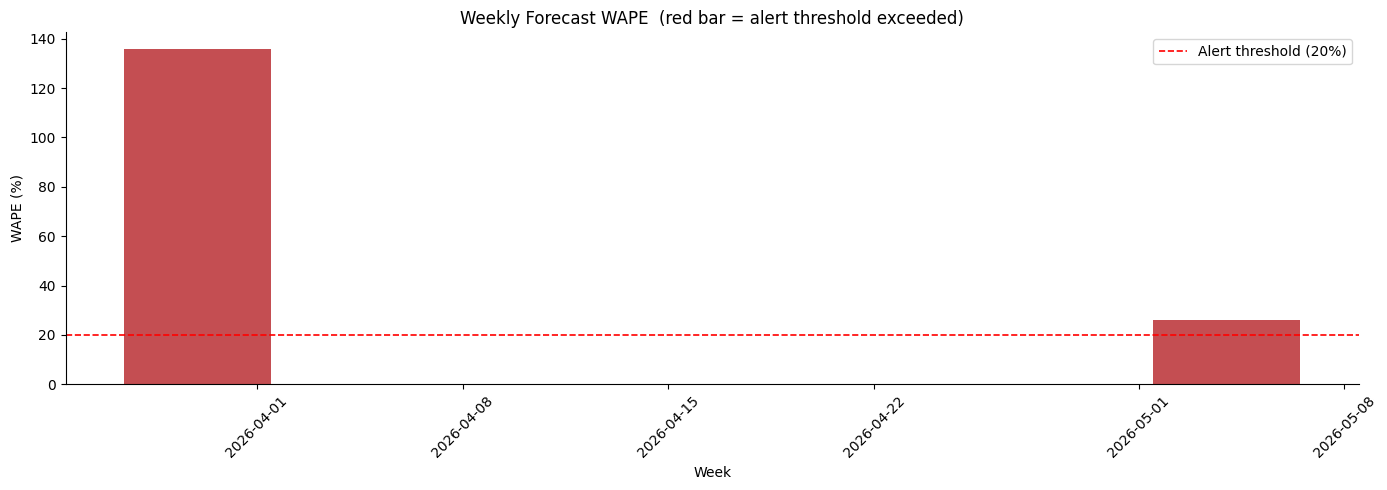

In [7]:
if len(weekly) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ["#C44E52" if w > WAPE_ALERT_THRESHOLD * 100 else "#4C72B0" for w in weekly["WAPE"]]
    ax.bar(weekly["week_start"], weekly["WAPE"], color=colors, width=5)
    ax.axhline(WAPE_ALERT_THRESHOLD * 100, color="red", ls="--", lw=1.2,
               label=f"Alert threshold ({WAPE_ALERT_THRESHOLD:.0%})")
    ax.set_title("Weekly Forecast WAPE  (red bar = alert threshold exceeded)")
    ax.set_ylabel("WAPE (%)")
    ax.set_xlabel("Week")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No evaluated weeks yet — run generate_weekly_forecast.py first, then wait for actuals to land in Supabase.")

### Chart 2 — Actual vs Predicted Units
> If the lines track each other closely, the model is doing its job.  
> A widening gap means the model is losing touch with reality — time to retrain.

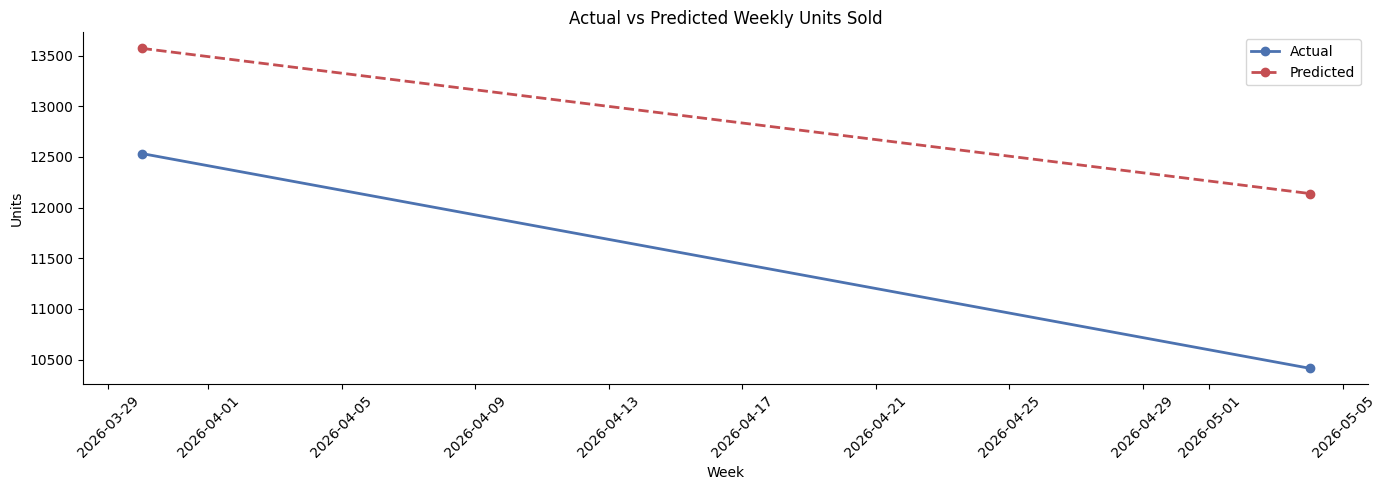

In [8]:
if len(weekly) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(weekly["week_start"], weekly["actual_sum"],    marker="o", label="Actual",    color=PALETTE[0], lw=2)
    ax.plot(weekly["week_start"], weekly["predicted_sum"], marker="o", label="Predicted", color=PALETTE[1], lw=2, ls="--")
    ax.set_title("Actual vs Predicted Weekly Units Sold")
    ax.set_ylabel("Units")
    ax.set_xlabel("Week")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No evaluated weeks yet.")

### Chart 3 — Bias Over Time
> Positive bias = model over-predicts (orders too much stock).  
> Negative bias = model under-predicts (risk of stockouts).  
> Both are bad — a good model hovers around 0.

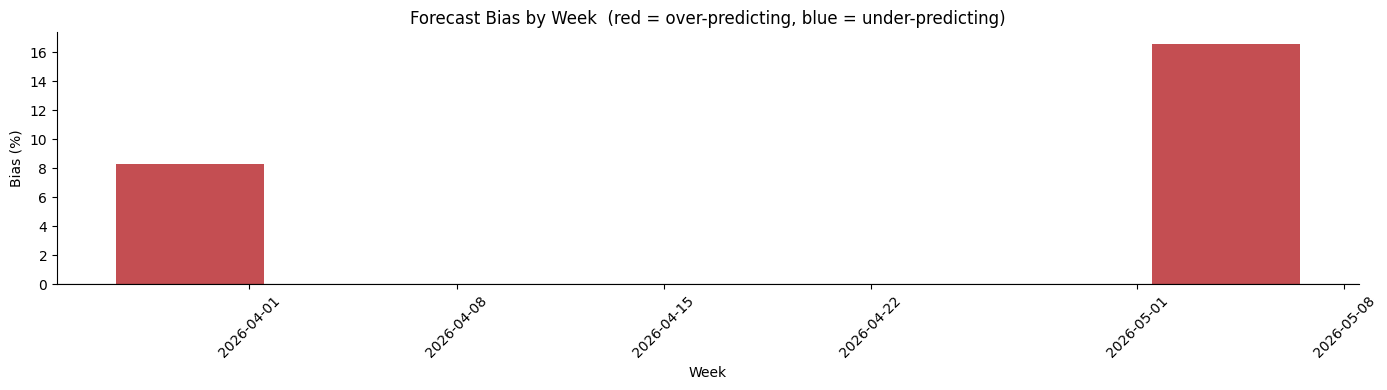

In [9]:
if len(weekly) > 0:
    fig, ax = plt.subplots(figsize=(14, 4))
    colors = ["#C44E52" if b > 0 else "#4C72B0" for b in weekly["BIAS_PCT"]]
    ax.bar(weekly["week_start"], weekly["BIAS_PCT"], color=colors, width=5)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title("Forecast Bias by Week  (red = over-predicting, blue = under-predicting)")
    ax.set_ylabel("Bias (%)")
    ax.set_xlabel("Week")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No evaluated weeks yet.")

---
## 7. Worst Performing Store × Product Combinations

> Pinpoints exactly which store-product pairs the model struggles with most.  
> These are candidates for separate models or manual overrides.

In [10]:
if len(evaluated) > 0:
    worst = (evaluated.groupby(["store_id", "product_id"])
             .agg(
                 avg_actual    =("units_sold",       "mean"),
                 avg_predicted =("predicted_units",  "mean"),
                 avg_abs_error =("abs_error",         "mean"),
                 wape          =("abs_error",         "sum"),
             )
             .reset_index())

    actual_sum_by_sp = evaluated.groupby(["store_id","product_id"])["units_sold"].sum()
    worst["wape"] = (worst["wape"] / worst["store_id"].map(
        evaluated.groupby("store_id")["units_sold"].sum()
    )).round(4)

    worst = worst.sort_values("avg_abs_error", ascending=False).head(20)
    worst["avg_actual"]    = worst["avg_actual"].round(2)
    worst["avg_predicted"] = worst["avg_predicted"].round(2)
    worst["avg_abs_error"] = worst["avg_abs_error"].round(2)

    print("Top 20 worst store × product combinations by average absolute error:")
    display(worst.reset_index(drop=True))
else:
    print("No evaluated rows yet.")

Top 20 worst store × product combinations by average absolute error:


,store_id,product_id,avg_actual,avg_predicted,avg_abs_error,wape
0,1,1029,289.0,123.36,169.28,0.0650
1,2,1071,231.5,119.90,160.14,0.0886
2,1,1071,238.5,115.14,154.04,0.0591
3,5,1095,154.5,94.64,141.09,0.1039
4,1,1045,0.5,140.12,139.62,0.0536
5,2,1029,180.5,88.68,130.18,0.0720
6,1,1031,51.0,179.32,128.32,0.0493
7,1,1093,32.5,156.88,124.38,0.0477
8,1,1104,190.5,108.90,118.82,0.0456
9,3,1029,204.5,86.62,117.88,0.0712


---
## 8. Future Weeks — Waiting for Actuals

> These forecast weeks don't have actuals yet.  
> They will become evaluable once you run the Saturday upload script.

In [11]:
pending = monitor[monitor["units_sold"].isna()][["week_start", "model_version"]].drop_duplicates()

if len(pending):
    print("Forecast weeks pending actuals:")
    display(pending.reset_index(drop=True))
    print(f"\nRun generate_upload_to_supabase.py after {pending['week_start'].max().date()} to unlock these.")
else:
    print("All forecast weeks have actuals — fully evaluated.")

Forecast weeks pending actuals:


,week_start,model_version
0,2026-05-11,weekly_model_v3_calendar
1,2026-05-11,weekly_model_v3_calendar_2026_05



Run generate_upload_to_supabase.py after 2026-05-11 to unlock these.
